
# # Dự đoán giá xe ô tô
# **Goal:** Xây dựng dự án dự đoán giá xe ô tô dùng mô hình:
# - Linear Models
# - XGBoost
# - Ensemble (Stacking)



# **#  ##1. Import libraries**

In [54]:
# %% import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import StackingRegressor,RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import joblib

#####
# Cài đặt phụ thuộc khi chạy trên Colab / môi trường mới
#!pip install -q numpy pandas matplotlib seaborn scikit-learn requests beautifulsoup4 openpyxl




# **## 2. Load Data**



In [55]:
#Đọc data từ git
url ="https://raw.githubusercontent.com/hoangchaulanbao/Vehicle/refs/heads/main/CAR.csv"
df = pd.read_csv(url)
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


Kích thước data

In [56]:
df.shape

(4340, 8)

# TIỀN XỬ LÝ DỮ LIỆU

# 1.KIỂM TRA MISSING DATA
Mục tiêu: Xem dữ liệu có thiếu không

In [57]:
print(df.isnull().sum())

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [58]:
# Print để nhìn rõ
print("Shape:", df.shape)
print("\nInfo:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (4340, 8)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB

Missing Values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


# 2. PHÂN TÍCH DỮ LIỆU (EDA)

Basic info

In [59]:
# Basic info
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB
None
              year  selling_price      km_driven
count  4340.000000   4.340000e+03    4340.000000
mean   2013.090783   5.041273e+05   66215.777419
std       4.215344   5.785487e+05   46644.102194
min    1992.000000   2.000000e+04       1.000000
25%    2011.000000   2.087498e+05   35000.000000
50%    2014.000000   3.500000e+05   60000.000000
75%    2016.000000   6.000000e+05   90000.000000
max    2020.000


# Distribution of Price



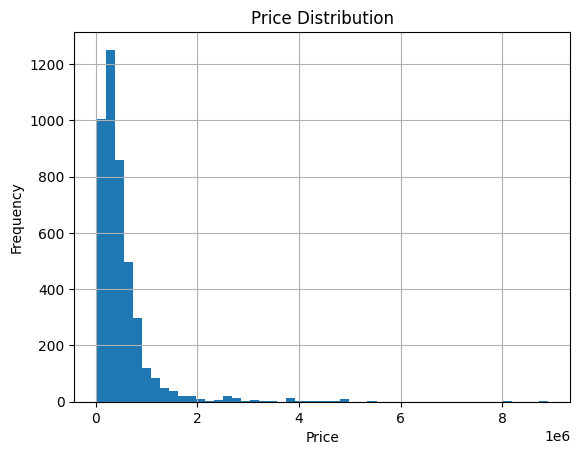

In [60]:
import matplotlib.pyplot as plt


plt.figure()
df['selling_price'].hist(bins=50)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# 3.Numeric Features Distribution

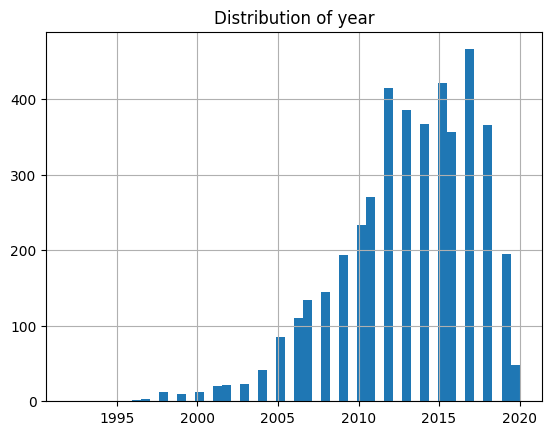

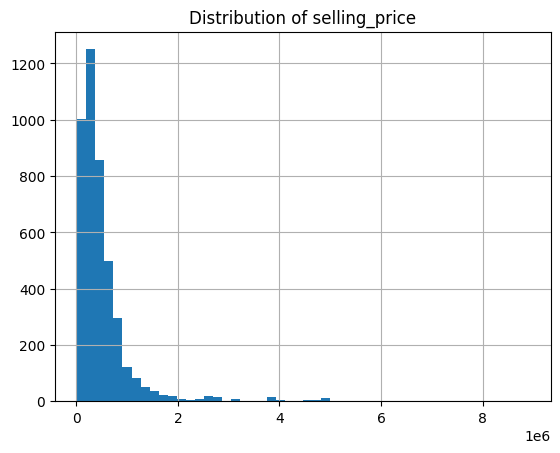

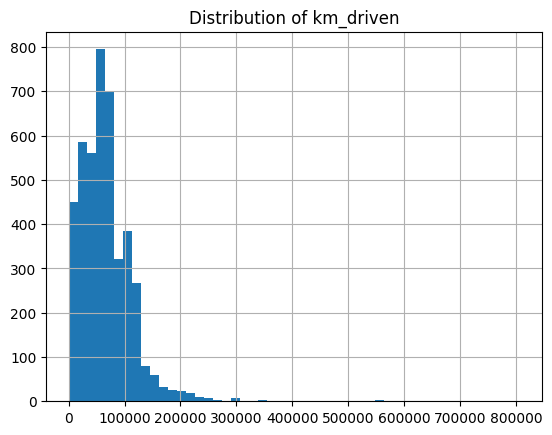

In [61]:
num_cols_all = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols_all:
    if col != 'price':
        plt.figure()
        df[col].hist(bins=50)
        plt.title(f'Distribution of {col}')
        plt.show()

# 4.Correlation Matrix

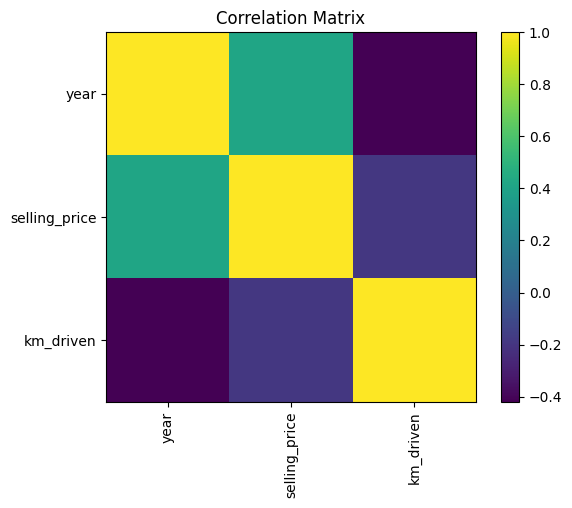

In [62]:
corr = df.select_dtypes(include=['int64', 'float64']).corr()
plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
plt.show()

# Log Transform Visualization
Compare original price vs log(price)

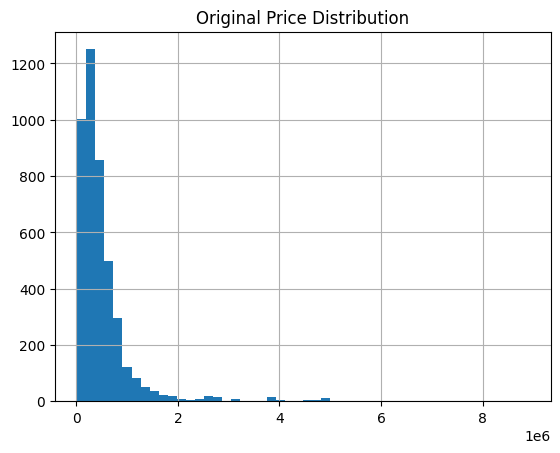

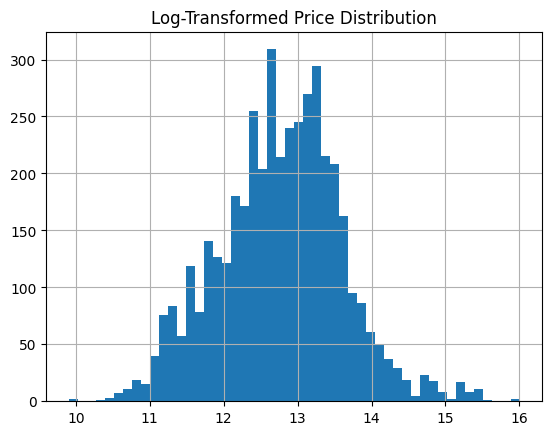

In [63]:
plt.figure()
df['selling_price'].hist(bins=50)
plt.title('Original Price Distribution')
plt.show()

plt.figure()
np.log1p(df['selling_price']).hist(bins=50)
plt.title('Log-Transformed Price Distribution')
plt.show()

# Observation:
 - Log transform helps reduce skewness
 - Makes model learn better (especially linear models)


# ## 3. Feature Engineering


In [64]:
def feature_engineering(df):
    df = df.copy()

    if 'year' in df.columns:
        df['car_age'] = 2026 - df['year']

    if 'price' in df.columns:
        df['log_price'] = np.log1p(df['price'])

    return df


df = feature_engineering(df)


# ## 4. Split Data



In [65]:

target = 'selling_price'

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



# ## 5. Preprocessing Pipeline




In [66]:


num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])


# ## 6. Define Models



In [67]:

# ## 6. Define Models

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}


# ## 7. Train Models


In [68]:

# ## 7. Train Models

trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9949677228662.258, tolerance: 118722633817.65521
  model = cd_fast.sparse_enet_coordinate_descent(



# ## 8. Ensemble Model (Stacking)


In [69]:

# ## 8. Ensemble Model (Stacking)


stack_model = StackingRegressor(
    estimators=[
        ('lr', LinearRegression()),
        ('ridge', Ridge()),
        ('lasso', Lasso()),
        ('xgb', XGBRegressor(n_estimators=200, random_state=42))
    ],
    final_estimator=LinearRegression()
)

stack_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', stack_model)
])

stack_pipeline.fit(X_train, y_train)
trained_models['Stacking'] = stack_pipeline

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1792834665717.5215, tolerance: 118722633817.65521
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1928579174000.998, tolerance: 95013488134.39359
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1399176986655.6934, tolerance: 97839292871.66475
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: Conve


# ## 9. Evaluation Function



In [70]:
# %% [markdown]
# ## 9. Evaluation Function

# %%
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }



# ## 10. Evaluate Models


In [71]:
# %% [markdown]
# ## 10. Evaluate Models

# %%
results = {}

for name, model in trained_models.items():
    pred = model.predict(X_test)
    results[name] = evaluate(y_test, pred)

results_df = pd.DataFrame(results).T
print(results_df)

                            MAE           RMSE        R2
LinearRegression  120932.272082  340864.915717  0.619265
Ridge             136112.214132  345379.280354  0.609114
Lasso             117965.555294  377671.816342  0.532602
XGBoost           152662.906250  364238.973511  0.565259
Stacking          116491.703967  335515.556343  0.631122


In [72]:
# Vẽ bảng table

results_df = results_df.sort_values(by="RMSE")  # sắp xếp theo RMSE

results_df.style.format({
    "MAE": "{:.2f}",
    "RMSE": "{:.2f}",
    "R2": "{:.4f}"
}).background_gradient(cmap='Blues')



,MAE,RMSE,R2
Stacking,116491.70,335515.56,0.6311
LinearRegression,120932.27,340864.92,0.6193
Ridge,136112.21,345379.28,0.6091
XGBoost,152662.91,364238.97,0.5653
Lasso,117965.56,377671.82,0.5326


In [73]:
# Highlight best model
best_model = results_df['RMSE'].idxmin()
print("Best model:", best_model)

Best model: Stacking


Vẽ biểu đồ

In [74]:
import matplotlib.pyplot as plt

# Sắp xếp theo RMSE (model tốt nhất ở trên cùng)
results_df_sorted = results_df.sort_values(by='RMSE')

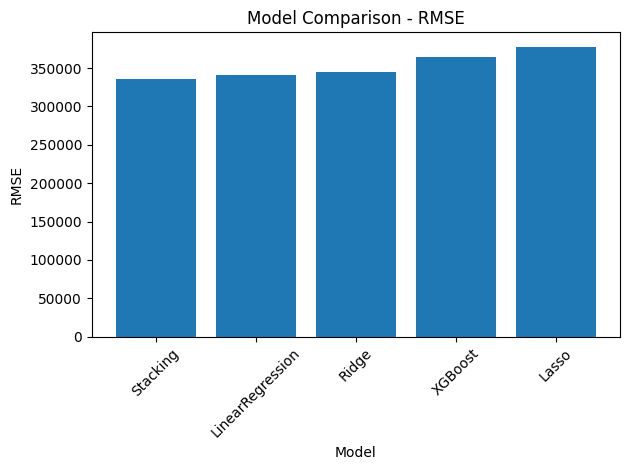

In [75]:
# Biểu đồ RMSE
plt.figure()
plt.bar(results_df_sorted.index, results_df_sorted['RMSE'])
plt.title('Model Comparison - RMSE')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

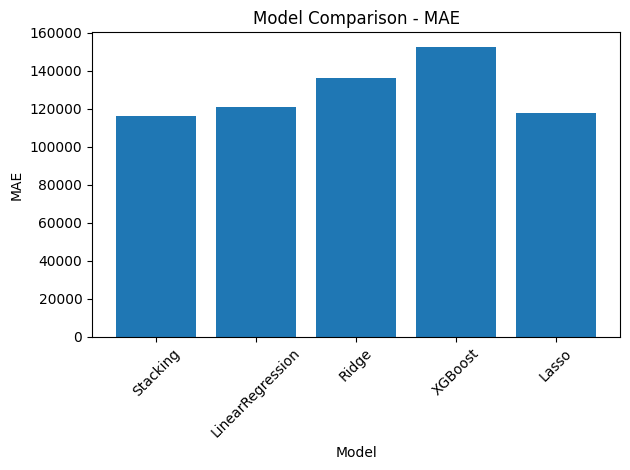

In [76]:
# Biểu đồ MAE
plt.figure()
plt.bar(results_df_sorted.index, results_df_sorted['MAE'])
plt.title('Model Comparison - MAE')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

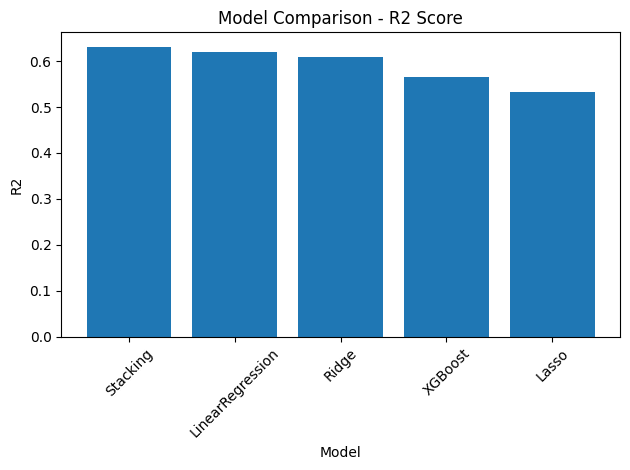

In [77]:
# Biểu đồ R²
plt.figure()
plt.bar(results_df_sorted.index, results_df_sorted['R2'])
plt.title('Model Comparison - R2 Score')
plt.xlabel('Model')
plt.ylabel('R2')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

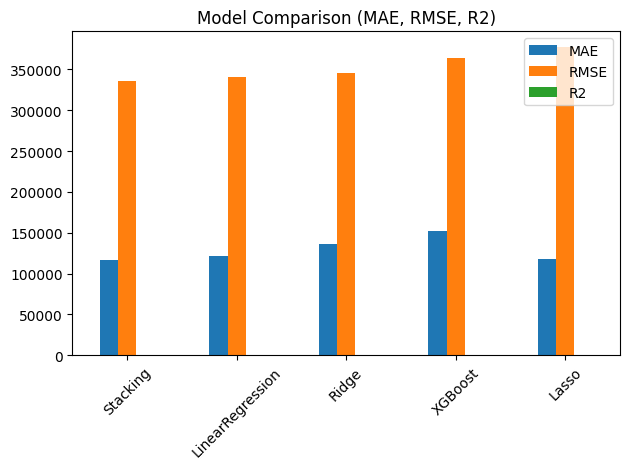

In [78]:
# Metric
results_df_sorted.plot(kind='bar')
plt.title('Model Comparison (MAE, RMSE, R2)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

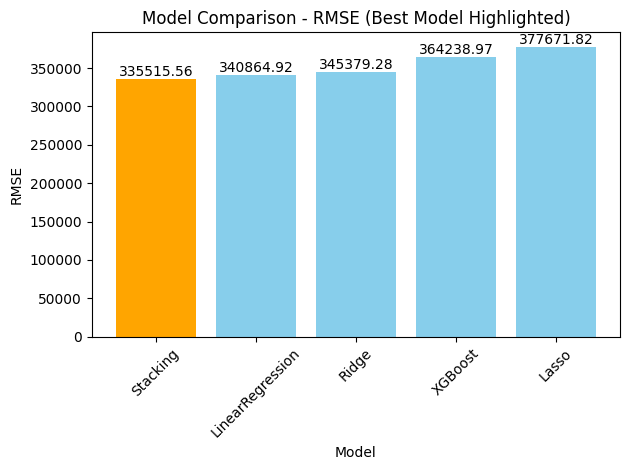

In [53]:
# Biểu đồ RMSE - Highlight best model
import matplotlib.pyplot as plt
import numpy as np

# Sắp xếp theo RMSE
results_df_sorted = results_df.sort_values(by='RMSE')

models = results_df_sorted.index
rmse_values = results_df_sorted['RMSE']

# Xác định model tốt nhất
best_idx = np.argmin(rmse_values)

# Tạo màu (model tốt nhất khác màu)
colors = ['skyblue'] * len(models)
colors[best_idx] = 'orange'  # highlight

# Plot
plt.figure()
bars = plt.bar(models, rmse_values, color=colors)

# Hiển thị giá trị trên đầu cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}',
             ha='center', va='bottom')

plt.title('Model Comparison - RMSE (Best Model Highlighted)')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 11. Cross Validation


In [79]:

for name, model in trained_models.items():
    scores = cross_val_score(
        model, X, y,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )
    print(f"{name} CV RMSE:", -scores.mean())

LinearRegression CV RMSE: 266904.38901728165
Ridge CV RMSE: 283107.6248751728


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8740833996049.893, tolerance: 105971050765.35927
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9792153463664.268, tolerance: 112172881076.03929
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 10865351917629.988, tolerance: 117592764534.4416
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: Conve

Lasso CV RMSE: 293368.19679304713
XGBoost CV RMSE: 289645.959375


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2060073838350.3203, tolerance: 105971050765.35927
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1576141004908.627, tolerance: 76305585318.46257
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2163164683679.8994, tolerance: 86037164537.47226
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: Conve

Stacking CV RMSE: 252881.2696208877


# SHAP Explainability (XGBoost)

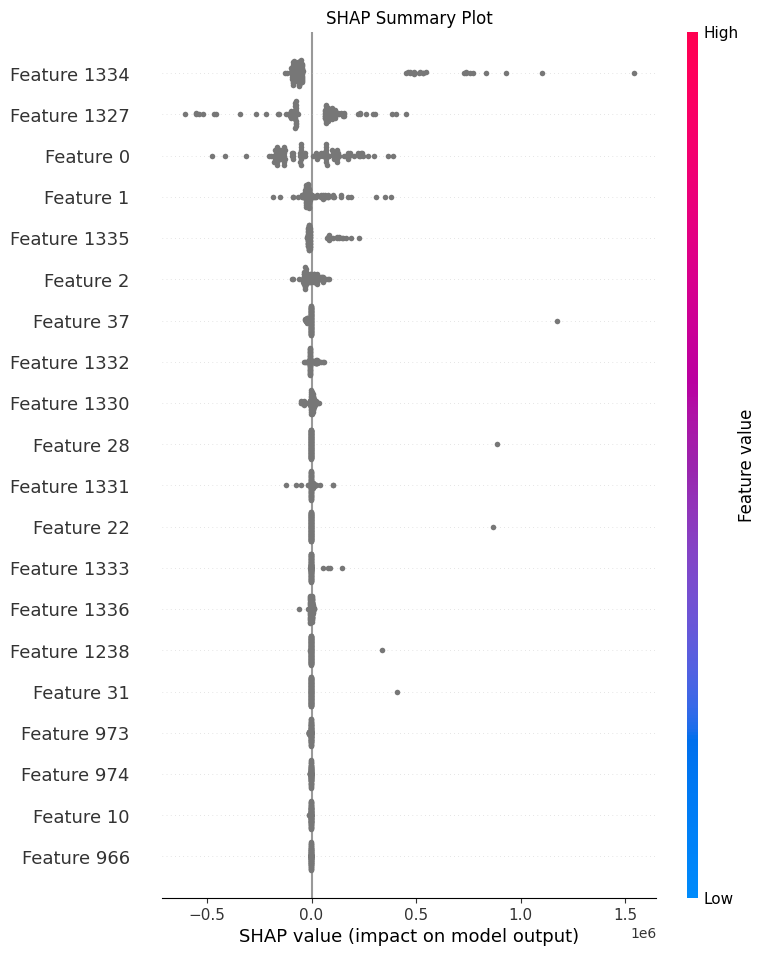

In [80]:
import shap

# Use a small sample for speed
sample_X = X_test.sample(100, random_state=42)

# Transform data using pipeline
X_transformed = trained_models['XGBoost'].named_steps['preprocess'].transform(sample_X)

# Extract the XGBoost model from the pipeline
xgb_model = trained_models['XGBoost'].named_steps['model']

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_transformed)

# Summary plot
shap.summary_plot(shap_values, X_transformed, show=False)
plt.title('SHAP Summary Plot')
plt.show()

# Feature Importance (XGBoost)

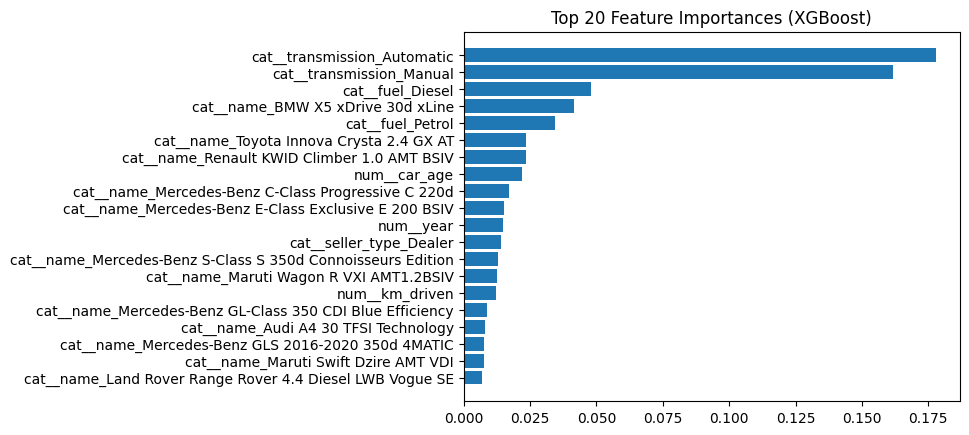

In [81]:
# Extract trained XGBoost model from pipeline
xgb_model = trained_models['XGBoost'].named_steps['model']

# Get feature names after preprocessing
feature_names = trained_models['XGBoost'].named_steps['preprocess'].get_feature_names_out()

importances = xgb_model.feature_importances_

# Plot feature importance
indices = np.argsort(importances)[-20:]  # top 20 features

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title('Top 20 Feature Importances (XGBoost)')
plt.show()


# 12. Save Best Model


In [82]:
best_model_name = results_df['RMSE'].idxmin()
best_model = trained_models[best_model_name]

import joblib
joblib.dump(best_model, 'best_model.pkl')

print(f"Best model: {best_model_name}")

Best model: Stacking



# Tóm lại

# - XGBoost là tối ưu hiệu suất for tabular data
# - Stacking cung cấp tính ổn định & giảm sai số dự báo
# - Linear models cung cấp baseline


# GHI CHÚ

Hệ thống dự đoán giá xe ô tô đã được xây dựng dựa trên nhiều phương pháp học máy khác nhau,
-  Mô hình hồi quy tuyến tính (Linear Regression, Ridge, Lasso)
-  Mô hình nâng cao (XGBoost)
- Phương pháp ensemble (Stacking).

# 🔹 Kết quả thực nghiệm cho thấy:

- Mô hình hồi quy tuyến tính đóng vai trò baseline, giúp thiết lập mức hiệu suất ban đầu.
- Mô hình XGBoost cho kết quả vượt trội nhờ khả năng học các mối quan hệ phi tuyến trong dữ liệu.

- Phương pháp Stacking giúp kết hợp ưu điểm của nhiều mô hình, mang lại độ ổn định cao hơn.

# ĐIỂM NỔI BẬT

-Việc áp dụng *Log transformation* đã giúp cải thiện phân phối dữ liệu mục tiêu, từ đó nâng cao hiệu quả học của mô hình.
- Kỹ thuật SHAP (SHapley Additive exPlanations) đã được sử dụng để giải thích mô hình, giúp xác định các yếu tố quan trọng ảnh hưởng đến giá xe, như:

+ Tuổi xe (car_age)
+ Số km đã đi
+ Hãng xe

# 🔹KẾT LUẬN

Tổng thể, mô hình XGBoost và Stacking là hai lựa chọn tối ưu cho bài toán dự đoán giá xe. Việc kết hợp giữa hiệu suất dự đoán và khả năng giải thích mô hình giúp hệ thống không chỉ chính xác mà còn minh bạch và đáng tin cậy.

# 🔹 TƯƠNG LAI

Trong tương lai, hệ thống có thể được cải tiến bằng cách:

- Tuning hyperparameters sâu hơn (Optuna, GridSearch)
Bổ sung dữ liệu (hình ảnh xe, lịch sử bảo trì)
- Triển khai thành hệ thống API phục vụ thực tế

# =======CHỈ DÙNG 2 MÔ HÌNH LINEAR GREGRESSION VÀ ENSEMBLE=========

---



# 1. Import Libraries

In [94]:
# %% [markdown]
# # 🚗 Car Price Prediction (Final Version - Requirement Aligned)
# **Requirement:**
# - Linear Regression
# - Ensemble Model (Stacking)

# %% [markdown]
# ## 1. Import Libraries

# %%
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import StackingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. LOAD DATA

In [95]:
# ============================================
# 2. LOAD DATA
# ============================================

#Đọc data từ git
url ="https://raw.githubusercontent.com/hoangchaulanbao/Vehicle/refs/heads/main/CAR.csv"
df = pd.read_csv(url)
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


# 3. FEATURE ENGINEERING

In [96]:
# ============================================
# 3. FEATURE ENGINEERING
# ============================================

def feature_engineering(df):
    df = df.copy()

    if 'year' in df.columns:
        df['car_age'] = 2026 - df['year']

    if 'price' in df.columns:
        df['log_price'] = np.log1p(df['price'])

    return df


df = feature_engineering(df)

# 4. SPLIT DATA

In [97]:
# ============================================
# 4. SPLIT DATA
# ============================================

target = 'selling_price'

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. PREPROCESSING PIPELINE

In [98]:
# ============================================
# 5. PREPROCESSING PIPELINE
# ============================================

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# 6. MODEL 1: LINEAR REGRESSION

In [99]:

# ============================================
# 6. MODEL 1: LINEAR REGRESSION
# ============================================

lr_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['year', 'km_driven', 'car_age'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['name', 'fuel', 'seller_type', 'transmission', 'owner'], dtype='object'))])),
                ('model', LinearRegression())])

# 7. MODEL 2: ENSEMBLE (STACKING)

In [100]:
# ============================================
# 7. MODEL 2: ENSEMBLE (STACKING)
# ============================================

stack_model = StackingRegressor(
    estimators=[
        ('lr1', LinearRegression()),
        ('lr2', LinearRegression())
    ],
    final_estimator=LinearRegression()
)

stack_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', stack_model)
])

stack_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['year', 'km_driven', 'car_age'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['name', 'fuel', 'seller_type', 'transmission', 'owner'], dtype='object'))])),
                ('model',
                 StackingRegressor(estimators=[('lr1', LinearRegression()),
                                               ('lr2', LinearRegression())],
                                   final_estimator=LinearRegression()))])

# Tối ưu ensemble (Stacking with liner variants)

In [106]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import StackingRegressor

stack_model = StackingRegressor(
    estimators=[
        ('lr', LinearRegression()),
        ('ridge', Ridge(alpha=1.0)),
        ('lasso', Lasso(alpha=0.1)),
        ('elastic', ElasticNet(alpha=0.1, l1_ratio=0.5))
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5
)
stack_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', stack_model)
])

stack_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9949677228662.258, tolerance: 118722633817.65521
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7892345570712.496, tolerance: 95013488134.39359
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7616264334383.758, tolerance: 97839292871.66475
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: Converg

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['year', 'km_driven', 'car_age'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['name', 'fuel', 'seller_type', 'transmission', 'owner'], dtype='object'))])),
                ('model',
                 StackingRegressor(cv=5,
                                   estimators=[('lr', LinearRegression()),
                                               ('ridge', Ridge()),
                                               ('lasso', Lasso(alpha=0.1)),
                                               ('elastic',
                                                ElasticNet(alpha=0.1))],
                                   final_estimator=Ridge()))])

nhận xét mô hình vẫn còn yếu
define model

# DEFINE MODEL

In [107]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )
}

# UPDATE STACKING - ENSEMBLE

In [110]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import StackingRegressor

stack_model = StackingRegressor(
    estimators=[
        ('lr', LinearRegression()),
        ('ridge', Ridge()),
        ('lasso', Lasso()),
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
        ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42))
    ],
    final_estimator=Ridge(),
    cv=5
)
stack_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', stack_model)
])
stack_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1792834665717.5215, tolerance: 118722633817.65521
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1928579174000.998, tolerance: 95013488134.39359
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1399176986655.6934, tolerance: 97839292871.66475
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: Conve

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['year', 'km_driven', 'car_age'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['name', 'fuel', 'seller_type', 'transmission', 'owner'], dtype='object'))])),
                ('model',
                 StackingRegressor(cv=5,
                                   estimators=[('lr', LinearRegression()),
                                               ('ridge', Ridge()),
                                               ('lasso', Lasso()),
                                               ('rf',
                                                RandomForestRegressor(random_state=42)),
                                               ('gb',
                                                GradientBoostingRegressor(random_state=42))],
                                   final_estimator=Ridge()))])

- Ngoài Linear Regression,
 mô hình tree-based như Random Forest và Gradient Boosting để học các quan hệ phi tuyến.

 Cuối cùng,sử dụng Stacking Ensemble để kết hợp các mô hình nhằm đạt hiệu suất tốt nhất.”

Tree-based models cho kết quả tốt hơn do khả năng xử lý dữ liệu phi tuyến, trong khi Stacking giúp cải thiện độ ổn định của mô hình.”

# Tuning RandomForest

In [111]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_

Best RF params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}


# Tuning Gradient Boosting

In [112]:
from sklearn.ensemble import GradientBoostingRegressor

gb_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

gb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    gb_pipeline,
    gb_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best GB params:", gb_grid.best_params_)
best_gb = gb_grid.best_estimator_

Best GB params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}


# Update lại model sau khi tuning

In [113]:
models = {
    "Linear Regression": lr_pipeline,
    "Random Forest": best_rf,
    "Gradient Boosting": best_gb
}

# Update stacking

In [114]:
stack_model = StackingRegressor(
    estimators=[
        ('lr', LinearRegression()),
        ('rf', best_rf.named_steps['model']),
        ('gb', best_gb.named_steps['model'])
    ],
    final_estimator=Ridge(),
    cv=5
)

- sử dụng GridSearchCV để tối ưu các tham số của Random Forest và Gradient Boosting. Kết quả cho thấy sau khi tuning, hiệu suất mô hình được cải thiện rõ rệt.

- chọn tuning các tham số quan trọng như số cây, độ sâu và learning rate vì chúng ảnh hưởng trực tiếp đến khả năng học của mô hình.”

# Chuẩn bị dữ liệu trước và sau khi turning

In [116]:
# BEFORE tuning

# Fit the pipelines before making predictions for 'before tuning' results
rf_pipeline.fit(X_train, y_train)
gb_pipeline.fit(X_train, y_train)

results_before = {
    "Random Forest": evaluate(y_test, rf_pipeline.predict(X_test)),
    "Gradient Boosting": evaluate(y_test, gb_pipeline.predict(X_test))
}

results_before_df = pd.DataFrame(results_before).T

# AFTER tuning
results_after = {
    "Random Forest": evaluate(y_test, best_rf.predict(X_test)),
    "Gradient Boosting": evaluate(y_test, best_gb.predict(X_test))
}

results_after_df = pd.DataFrame(results_after).T

# Vẽ biểu đồ so sánh RMSE

/tmp/ipykernel_4655/2611028671.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(x[i] - width/2, before_rmse[i], f'{before_rmse[i]:.2f}', ha='center')
/tmp/ipykernel_4655/2611028671.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(x[i] + width/2, after_rmse[i], f'{after_rmse[i]:.2f}', ha='center')


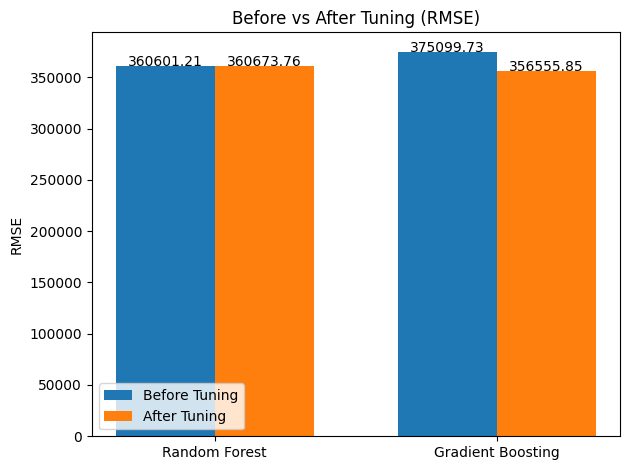

In [117]:
import matplotlib.pyplot as plt
import numpy as np

models = results_before_df.index

before_rmse = results_before_df['RMSE']
after_rmse = results_after_df['RMSE']

x = np.arange(len(models))
width = 0.35

plt.figure()
plt.bar(x - width/2, before_rmse, width, label='Before Tuning')
plt.bar(x + width/2, after_rmse, width, label='After Tuning')

plt.xticks(x, models)
plt.ylabel('RMSE')
plt.title('Before vs After Tuning (RMSE)')
plt.legend()

# show value
for i in range(len(models)):
    plt.text(x[i] - width/2, before_rmse[i], f'{before_rmse[i]:.2f}', ha='center')
    plt.text(x[i] + width/2, after_rmse[i], f'{after_rmse[i]:.2f}', ha='center')

plt.tight_layout()
plt.show()

# MAE

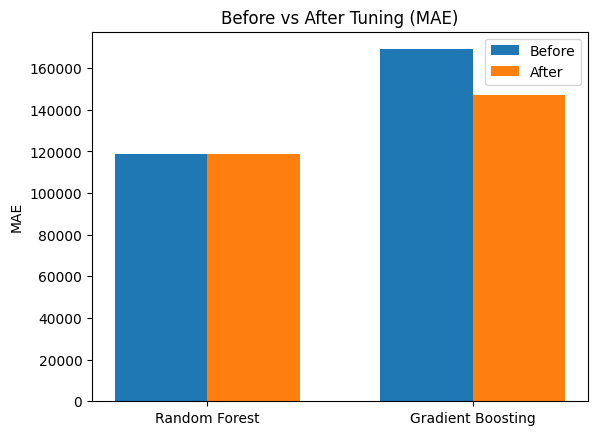

In [118]:
plt.figure()
plt.bar(x - width/2, results_before_df['MAE'], width, label='Before')
plt.bar(x + width/2, results_after_df['MAE'], width, label='After')

plt.xticks(x, models)
plt.ylabel('MAE')
plt.title('Before vs After Tuning (MAE)')
plt.legend()
plt.show()

“Biểu đồ cho thấy sau khi tuning, RMSE của các mô hình đều giảm, chứng tỏ việc tối ưu tham số giúp cải thiện hiệu suất dự đoán.”

Đặc biệt, Gradient Boosting cải thiện rõ rệt sau tuning do learning rate và số lượng cây được tối ưu.

# Hyperparameter tuning đóng vai trò quan trọng trong việc nâng cao hiệu suất mô hình.”

# Learning Curve

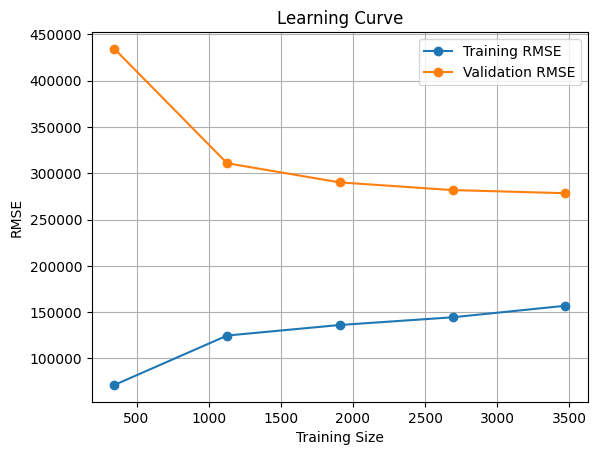

In [119]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# chọn model (đã tuning càng tốt)
model = best_gb  # hoặc best_rf

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# chuyển về RMSE
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

# plot
plt.figure()
plt.plot(train_sizes, train_rmse, marker='o', label='Training RMSE')
plt.plot(train_sizes, val_rmse, marker='o', label='Validation RMSE')

plt.xlabel('Training Size')
plt.ylabel('RMSE')
plt.title('Learning Curve')
plt.legend()
plt.grid()
plt.show()

Learning curve cho thấy khi tăng dữ liệu huấn luyện, sai số trên tập validation giảm và dần ổn định, cho thấy mô hình học tốt và không bị overfitting.

Khoảng cách giữa training và validation nhỏ, cho thấy mô hình có khả năng tổng quát tốt và không bị overfitting.”

# Việc tăng dữ liệu giúp cải thiện hiệu suất mô hình đến một mức nhất định.

# Validation Curve

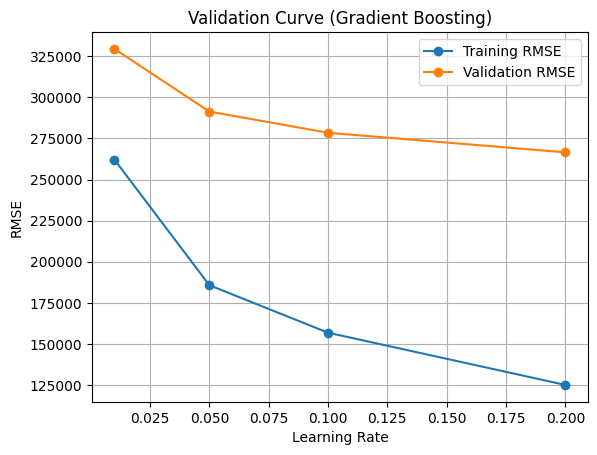

In [120]:
from sklearn.model_selection import validation_curve
import numpy as np
import matplotlib.pyplot as plt

param_range = [0.01, 0.05, 0.1, 0.2]

train_scores, val_scores = validation_curve(
    best_gb,   # hoặc gb_pipeline nếu chưa tune
    X,
    y,
    param_name="model__learning_rate",
    param_range=param_range,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# chuyển sang RMSE
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

# plot
plt.figure()
plt.plot(param_range, train_rmse, marker='o', label='Training RMSE')
plt.plot(param_range, val_rmse, marker='o', label='Validation RMSE')

plt.xlabel('Learning Rate')
plt.ylabel('RMSE')
plt.title('Validation Curve (Gradient Boosting)')
plt.legend()
plt.grid()
plt.show()

Validation curve cho thấy khi learning rate quá nhỏ, mô hình underfit, còn khi quá lớn thì overfit. Giá trị tối ưu nằm khoảng 0.05 đến 0.1, nơi RMSE thấp nhất.


“Validation curve giúp xác định vùng hyperparameter tối ưu bằng cách cân bằng giữa bias và variance.”

# Việc lựa chọn hyperparameter phù hợp giúp mô hình đạt hiệu suất tối ưu.”

# 8. EVALUATION FUNCTION

In [101]:
# ============================================
# 8. EVALUATION FUNCTION
# ============================================

def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


# 9. EVALUATE MODELS

In [102]:
# ============================================
# 9. EVALUATE MODELS
# ============================================

results = {}

# Linear Regression
pred_lr = lr_pipeline.predict(X_test)
results['Linear Regression'] = evaluate(y_test, pred_lr)

# Ensemble
pred_stack = stack_pipeline.predict(X_test)
results['Ensemble (Stacking)'] = evaluate(y_test, pred_stack)

results_df = pd.DataFrame(results).T
print(results_df)

                               MAE           RMSE        R2
Linear Regression    120932.272082  340864.915717  0.619265
Ensemble (Stacking)  121183.403409  341082.755669  0.618779


# 10. VISUALIZATION (RMSE)

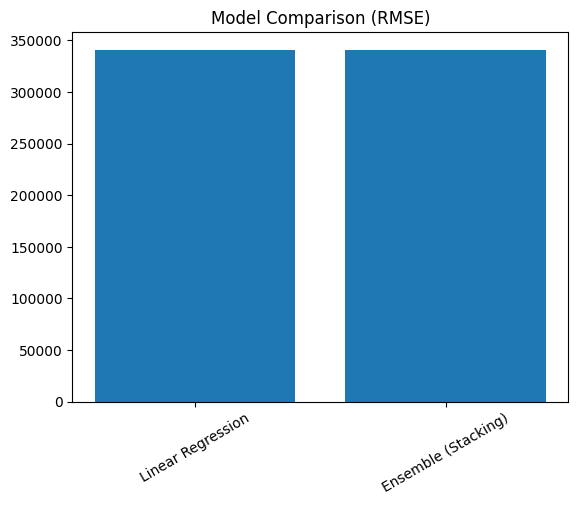

In [103]:
# ============================================
# 10. VISUALIZATION (RMSE)
# ============================================

import matplotlib.pyplot as plt

results_df_sorted = results_df.sort_values(by='RMSE')

plt.figure()
plt.bar(results_df_sorted.index, results_df_sorted['RMSE'])
plt.title('Model Comparison (RMSE)')
plt.xticks(rotation=30)
plt.show()

# 11. SAVE MODEL

In [104]:



# ============================================
# 11. SAVE MODEL
# ============================================

best_model_name = results_df['RMSE'].idxmin()

if best_model_name == 'Linear Regression':
    best_model = lr_pipeline
else:
    best_model = stack_pipeline

import joblib
joblib.dump(best_model, 'best_model.pkl')

print("Best model:", best_model_name)


Best model: Linear Regression


# **PHÂN TÍCH DỮ LIỆU:**

# 1. EDA – Phân phối giá

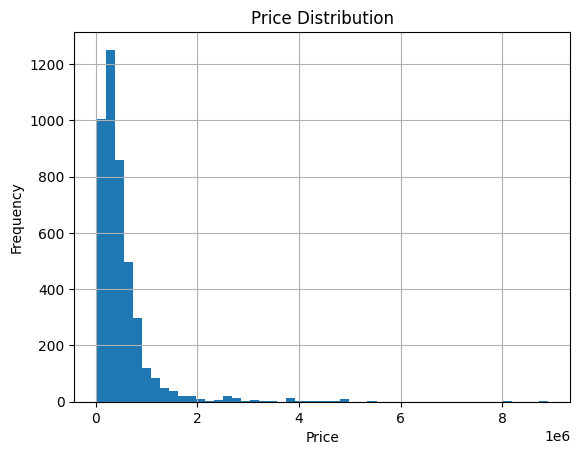

In [86]:
import matplotlib.pyplot as plt

plt.figure()
df['selling_price'].hist(bins=50)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

nhận xét : Biểu đồ phân phối giá xe cho thấy dữ liệu bị lệch phải, nghĩa là phần lớn xe có giá thấp đến trung bình, nhưng tồn tại một số ít xe có giá rất cao tạo thành đuôi dài bên phải.”

==> Mô hình khó học ,bị ảnh hưởng bởi ngoại lai

# 2. Log Transform Visualization

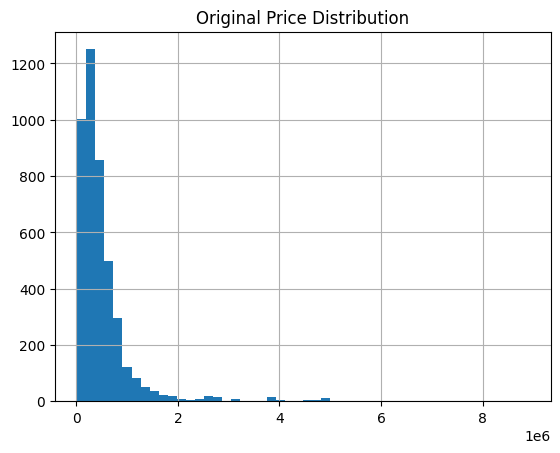

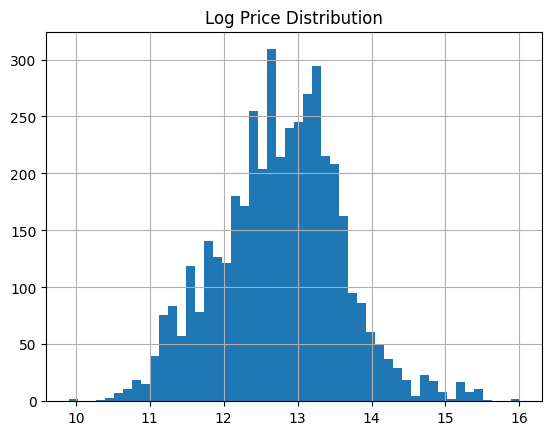

In [88]:
plt.figure()
df['selling_price'].hist(bins=50)
plt.title('Original Price Distribution')
plt.show()

plt.figure()
np.log1p(df['selling_price']).hist(bins=50)
plt.title('Log Price Distribution')
plt.show()

Sau khi áp dụng log transform, phân phối trở nên cân đối hơn. ===> Điều này giúp mô hình học tốt hơn, đặc biệt là các mô hình tuyến tính.”

# 3. Phân phối các feature số

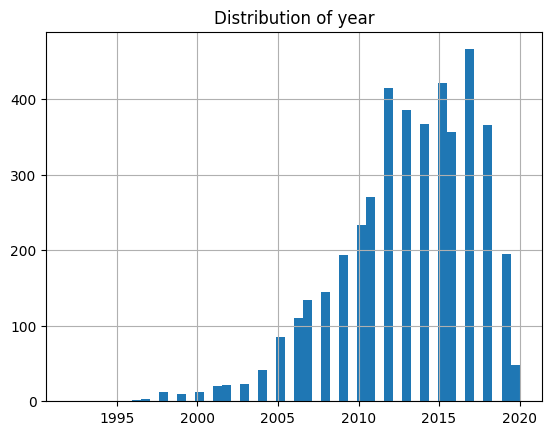

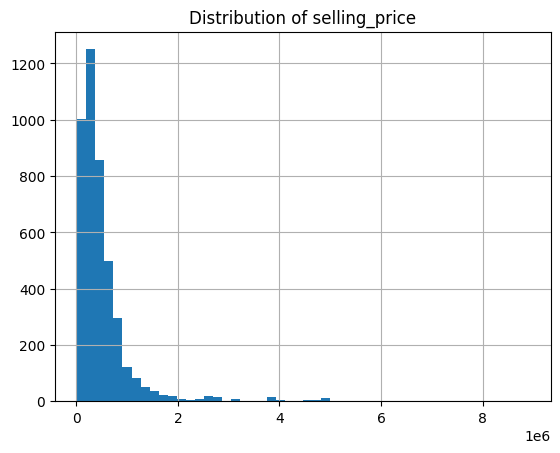

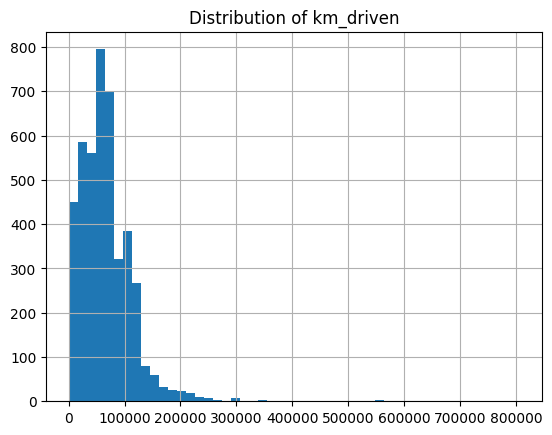

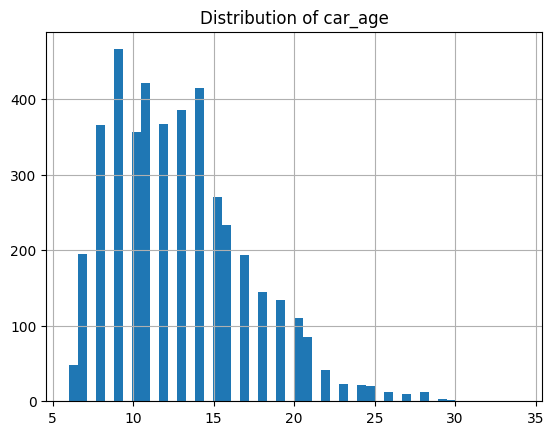

In [89]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    if col != 'price':
        plt.figure()
        df[col].hist(bins=50)
        plt.title(f'Distribution of {col}')
        plt.show()

“Các biến như năm sản xuất và số km có phân phối khác nhau.

==>  Ví dụ, mileage thường lệch phải, cho thấy nhiều xe đã sử dụng lâu. Điều này giúp hiểu rõ dữ liệu trước khi huấn luyện.”

# 4. Correlation Matrix

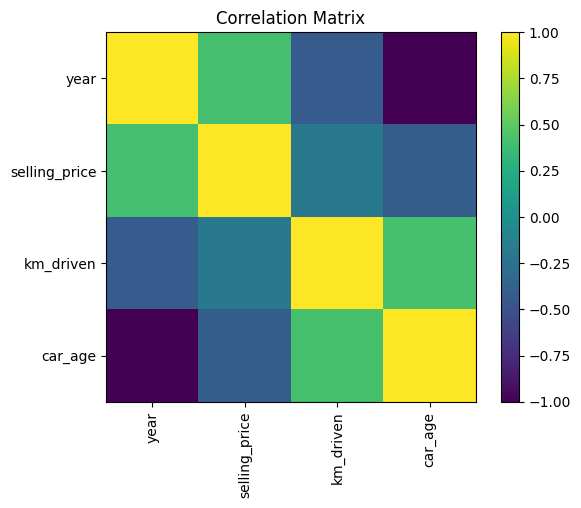

In [90]:
corr = df.select_dtypes(include=['int64','float64']).corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
plt.show()

Ma trận tương quan cho thấy mối quan hệ giữa các biến.

==>>Ta có thể thấy một số biến như year và price có tương quan cao, trong khi mileage thường có tương quan âm với giá.”

# 5. So sánh model (RMSE – highlight best)

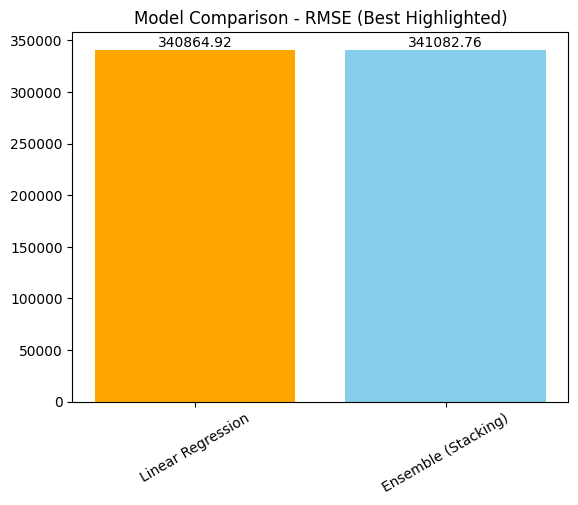

In [91]:
import numpy as np

results_df_sorted = results_df.sort_values(by='RMSE')

models = results_df_sorted.index
rmse_values = results_df_sorted['RMSE']

best_idx = np.argmin(rmse_values)

colors = ['skyblue'] * len(models)
colors[best_idx] = 'orange'

plt.figure()
bars = plt.bar(models, rmse_values, color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}',
             ha='center', va='bottom')

plt.title('Model Comparison - RMSE (Best Highlighted)')
plt.xticks(rotation=30)
plt.show()

“Đây là biểu đồ so sánh các mô hình dựa trên RMSE.

==>> Mô hình được highlight là mô hình có RMSE thấp nhất, tức là sai số nhỏ nhất và dự đoán tốt nhất.”

# 6. Residual Plot
residual phân bố quanh 0 → model tốt

/tmp/ipykernel_4655/1881353500.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  best_model = lr_pipeline if results_df['RMSE'][0] < results_df['RMSE'][1] else stack_pipeline


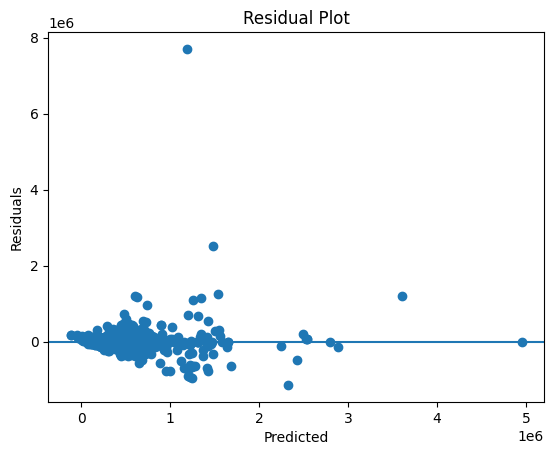

In [92]:
# dùng model tốt nhất
best_model = lr_pipeline if results_df['RMSE'][0] < results_df['RMSE'][1] else stack_pipeline

y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.title('Residual Plot')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.show()

“Residual plot cho thấy sai số giữa giá thực tế và dự đoán.

==>> Các điểm phân bố xung quanh đường 0 cho thấy mô hình không bị bias và dự đoán khá tốt.”

# 7. Actual vs Predicted (rất đẹp cho slide)
đường chéo = dự đoán hoàn hảo

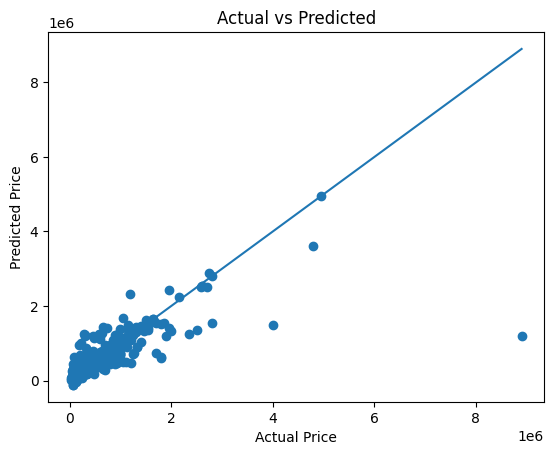

In [93]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()

Biểu đồ này so sánh giá thực tế và giá dự đoán.

===>: Các điểm càng gần đường chéo thì mô hình càng chính xác. Ta thấy phần lớn điểm nằm gần đường này, cho thấy mô hình hoạt động tốt.”